In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
!pip install -q transformers peft accelerate jiwer torchaudio datasets evaluate
!pip install -U torchao jiwer accelerate bitsandbytes -q

import os, glob, shutil, torch
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ── Paths ──────────────────────────────────────────────────
WHISPER_OUT = "/kaggle/working/whisper-en-lora"
GPT2_OUT    = "/kaggle/working/gpt2-en-continuation"
FLAN_OUT    = "/kaggle/working/flan-t5-continuation"
MODEL_NAME  = "openai/whisper-small"

# ── Auto-detect dataset ────────────────────────────────────
def autodetect_dataset_root():
    candidates = glob.glob("/kaggle/input/*")
    if not candidates:
        raise FileNotFoundError("No dataset found under /kaggle/input/.")
    print("Found:", candidates)
    return candidates[0]

DATASET_ROOT = autodetect_dataset_root()

# ── Restore saved models from previous run ─────────────────
# If you uploaded your final_model_output.zip as a Kaggle dataset,
# add it as input and it will be restored here automatically.
SAVED_MODELS = glob.glob("/kaggle/input/**/optimized_model_output")
if SAVED_MODELS:
    SAVED = SAVED_MODELS[0]
    print("Restoring saved models from:", SAVED)
    for model_dir in ["whisper-en-lora", "gpt2-en-continuation", "flan-t5-continuation"]:
        src = os.path.join(SAVED, model_dir)
        dst = f"/kaggle/working/{model_dir}"
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copytree(src, dst)
            print(f"  Restored: {model_dir}")
else:
    print("No saved models found — will train from scratch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 46.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 45.0 MB/s eta 0:00:00:00:0100:01
Device: cuda
Found: ['/kaggle/input/datasets']
No saved models found — will train from scratch


In [4]:
# ============================================================
# CELL 2: PHASE 1 — DATA AUDIT
# ============================================================
import unicodedata

def find_tsv_files(root):
    tsvs = glob.glob(os.path.join(root, "**", "*.tsv"), recursive=True)
    if not tsvs:
        raise FileNotFoundError(f"No .tsv files under {root}.")
    return tsvs

def find_clips_dir(root):
    direct = glob.glob(os.path.join(root, "**", "clips"), recursive=True)
    if direct:
        return direct[0]
    audio = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    if not audio:
        raise FileNotFoundError(f"No audio files under {root}.")
    return os.path.dirname(audio[0])

tsvs     = find_tsv_files(DATASET_ROOT)
preferred = [t for t in tsvs if os.path.basename(t) in ("train.tsv", "validated.tsv")]
main_tsv  = preferred[0] if preferred else max(tsvs, key=os.path.getsize)
print("Using:", main_tsv)

df = pd.read_csv(main_tsv, sep="\t")
print("Columns:", list(df.columns))
print("Total rows:", len(df))

CLIPS_DIR = find_clips_dir(DATASET_ROOT)
print("Clips dir:", CLIPS_DIR, "| files:", len(glob.glob(os.path.join(CLIPS_DIR, "*"))))

df["sentence_norm"] = (
    df["sentence"].astype(str)
    .apply(lambda s: unicodedata.normalize("NFC", s).strip().lower())
)
df_clean = df[df["sentence_norm"].str.len() > 0]
print(f"Rows after quality filter: {len(df_clean)} / {len(df)}")

Using: /kaggle/input/datasets/junaedkhandakar/librispeech-clean-en/librispeech/train.tsv
Columns: ['path', 'sentence', 'duration', 'language', 'label', 'source']
Total rows: 24019
Clips dir: /kaggle/input/datasets/junaedkhandakar/librispeech-clean-en/librispeech/clips | files: 28707
Rows after quality filter: 24019 / 24019


In [5]:
# ============================================================
# CELL 3: PHASE 2B — PREPARE DATASET FOR WHISPER
# ============================================================
from datasets import Dataset, Audio
from transformers import WhisperProcessor

N_TRAIN = 5000
N_EVAL  = 500

df_clean["audio_path"] = df_clean["path"].apply(lambda p: os.path.join(CLIPS_DIR, p))
df_clean = df_clean[df_clean["audio_path"].apply(os.path.exists)]
print(f"Rows with existing audio: {len(df_clean)}")

df_shuffled = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)
train_df    = df_shuffled.iloc[:N_TRAIN]
eval_df     = df_shuffled.iloc[N_TRAIN:N_TRAIN + N_EVAL]

train_ds = Dataset.from_pandas(train_df[["audio_path", "sentence_norm"]], preserve_index=False)
eval_ds  = Dataset.from_pandas(eval_df[["audio_path",  "sentence_norm"]], preserve_index=False)

train_ds = train_ds.cast_column("audio_path", Audio(sampling_rate=16000))
eval_ds  = eval_ds.cast_column("audio_path",  Audio(sampling_rate=16000))

processor = WhisperProcessor.from_pretrained(MODEL_NAME, language="en", task="transcribe")

def prepare_example(batch):
    audio = batch["audio_path"]
    batch["input_features"] = processor.feature_extractor(
        audio["array"], sampling_rate=16000
    ).input_features[0]
    batch["labels"] = processor.tokenizer(batch["sentence_norm"]).input_ids
    return batch

train_ds = train_ds.map(prepare_example, remove_columns=train_ds.column_names)
eval_ds  = eval_ds.map(prepare_example,  remove_columns=eval_ds.column_names)
print("Train:", len(train_ds), "| Eval:", len(eval_ds))

Rows with existing audio: 24019


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train: 5000 | Eval: 500


In [7]:
# ============================================================
# CELL 4: PHASE 2C — FINE-TUNE WHISPER WITH LoRA
# Checkpoint: skips if already trained
# ============================================================
import torch, evaluate
from transformers import (
    WhisperForConditionalGeneration,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback
)
from peft import get_peft_model, LoraConfig, TaskType
from dataclasses import dataclass
from typing import Any, Dict, List, Union

if os.path.exists(WHISPER_OUT) and any(
    "checkpoint" in d for d in os.listdir(WHISPER_OUT)
):
    print("Whisper already trained — skipping Cell 4")
    print("Checkpoints found:", [d for d in os.listdir(WHISPER_OUT) if "checkpoint" in d])
else:
    print("Starting Whisper training...")

    @dataclass
    class DataCollatorSpeechSeq2SeqWithPadding:
        processor: Any
        def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
            input_features = [{"input_features": f["input_features"]} for f in features]
            batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
            label_features = [{"input_ids": f["labels"]} for f in features]
            labels_batch   = self.processor.tokenizer.pad(label_features, return_tensors="pt")
            labels = labels_batch["input_ids"].masked_fill(
                labels_batch.attention_mask.ne(1), -100
            )
            if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
                labels = labels[:, 1:]
            batch["labels"] = labels
            return batch

    model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
    model.generation_config.forced_decoder_ids = None
    model.generation_config.suppress_tokens    = []

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=16, lora_alpha=32,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.1, bias="none"
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

    training_args = Seq2SeqTrainingArguments(
        output_dir=WHISPER_OUT,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        learning_rate=5e-4,
        warmup_steps=100,
        max_steps=800,
        weight_decay=0.01,
        fp16=True,
        eval_strategy="steps",
        eval_steps=100,
        save_steps=100,
        logging_steps=25,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="wer",
        greater_is_better=False,
        predict_with_generate=True,
        generation_max_length=225,
    )

    wer_metric = evaluate.load("wer")

    def compute_metrics(pred):
        pred_ids  = pred.predictions
        label_ids = pred.label_ids
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        pred_str  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
        label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
        return {"wer": wer_metric.compute(predictions=pred_str, references=label_str)}

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        processing_class=processor.feature_extractor,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    train_result = trainer.train()
    print(f"Training loss : {train_result.training_loss:.4f}")

Starting Whisper training...


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

trainable params: 1,769,472 || all params: 243,504,384 || trainable%: 0.7267


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Wer
100,1.406250,0.256019,0.086155
200,0.712672,0.227678,0.075559
300,0.786092,0.217875,0.072103
400,0.545308,0.222223,0.071873
500,0.415600,0.226704,0.072276
600,0.373290,0.228848,0.072737
700,0.319803,0.235897,0.073716


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

Training loss : 0.9599


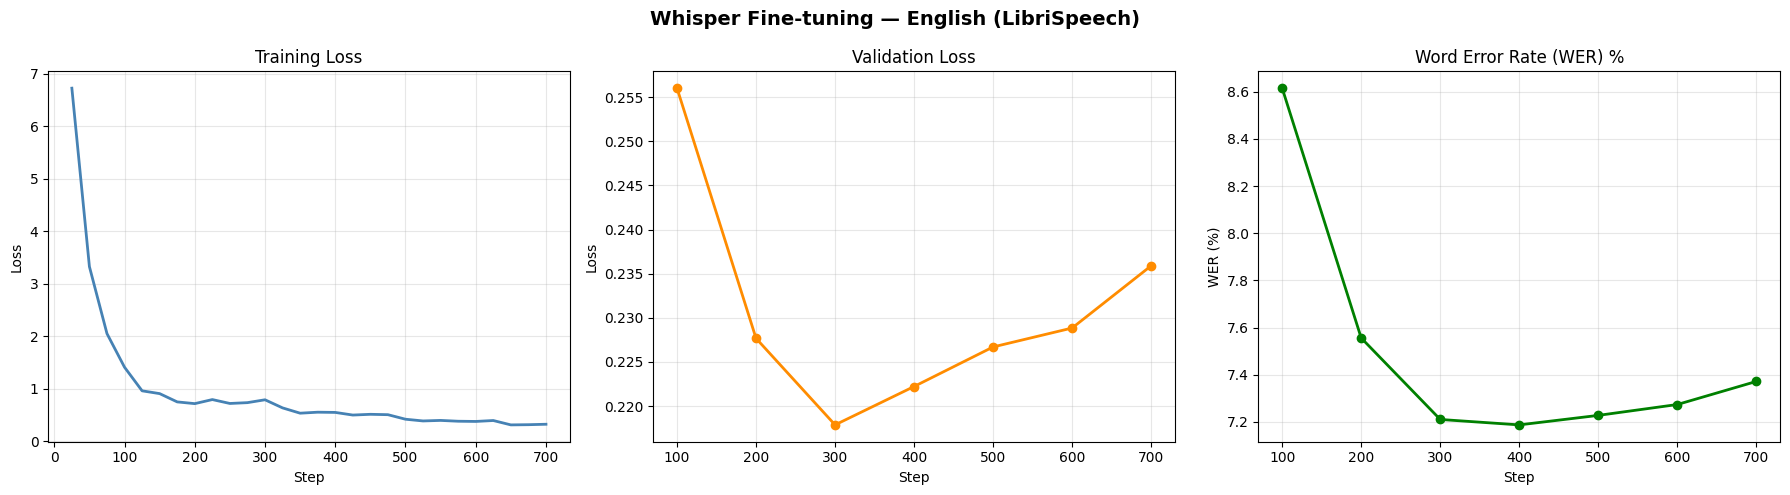

Best WER: 7.19% at step 400


In [8]:
# ============================================================
# CELL 5: WER / LOSS GRAPH
# Requires Cell 4 to have run (not skipped) in this session
# ============================================================
import matplotlib.pyplot as plt

try:
    log_history = trainer.state.log_history
except NameError:
    # Load from saved trainer state if Cell 4 was skipped
    import json
    state_files = glob.glob(f"{WHISPER_OUT}/checkpoint-*/trainer_state.json")
    if not state_files:
        print("No trainer state found — run Cell 4 first in this session")
        raise SystemExit
    with open(sorted(state_files)[-1]) as f:
        state = json.load(f)
    log_history = state["log_history"]

train_steps, train_losses         = [], []
eval_steps, eval_wers, eval_losses = [], [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_wer" in entry:
        eval_steps.append(entry["step"])
        eval_wers.append(entry["eval_wer"])
        eval_losses.append(entry["eval_loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Whisper Fine-tuning — English (LibriSpeech)", fontsize=14, fontweight="bold")

axes[0].plot(train_steps, train_losses, color="steelblue", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_steps, eval_losses, color="darkorange", linewidth=2, marker="o")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

axes[2].plot(eval_steps, [w * 100 for w in eval_wers], color="green", linewidth=2, marker="o")
axes[2].set_title("Word Error Rate (WER) %")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("WER (%)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

if eval_wers:
    best_idx = eval_wers.index(min(eval_wers))
    print(f"Best WER: {min(eval_wers)*100:.2f}% at step {eval_steps[best_idx]}")

In [9]:
# ============================================================
# CELL 6: EVALUATE WHISPER (WER / CER)
# Works even if Cell 4 was skipped (uses restored checkpoint)
# ============================================================
import jiwer
from peft import PeftModel
from transformers import WhisperForConditionalGeneration

# Auto-find best checkpoint
ckpt_configs = sorted(
    glob.glob(f"{WHISPER_OUT}/checkpoint-*/adapter_config.json")
)
if not ckpt_configs:
    raise FileNotFoundError("No checkpoint found. Run Cell 4 or restore from saved dataset.")

best_ckpt = os.path.dirname(ckpt_configs[-1])
print("Loading checkpoint:", best_ckpt)

base_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
ft_model   = PeftModel.from_pretrained(base_model, best_ckpt).to(device)
ft_model.eval()

refs, preds = [], []
for example in eval_ds.select(range(100)):
    input_feat = torch.tensor(example["input_features"]).unsqueeze(0).to(device)
    with torch.no_grad():
        predicted_ids = ft_model.generate(input_features=input_feat)
    pred_str = processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    ref_str  = processor.tokenizer.decode(
        [i for i in example["labels"] if i != -100], skip_special_tokens=True
    )
    refs.append(ref_str)
    preds.append(pred_str)

wer = jiwer.wer(refs, preds)
cer = jiwer.cer(refs, preds)
print(f"\nFine-tuned WER : {wer:.3f} ({wer*100:.1f}%)")
print(f"Fine-tuned CER : {cer:.3f} ({cer*100:.1f}%)")

print("\nSample comparisons (10):")
for r, p in zip(refs[:10], preds[:10]):
    print("REF :", r)
    print("PRED:", p)
    print("-" * 60)

Loading checkpoint: /kaggle/working/whisper-en-lora/checkpoint-700


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.



Fine-tuned WER : 0.322 (32.2%)
Fine-tuned CER : 0.197 (19.7%)

Sample comparisons (10):
REF : fell far short don't look back grunted ventnor stretch yourself walter there's a surprise coming hope to god i judged the time right we turned off the ruined way
PRED: bebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebebeb

In [10]:
# ============================================================
# CELL 7: PHASE 3 — LOAD ENGLISH TEXT CORPUS (WIKIPEDIA)
# ============================================================

from datasets import load_dataset
import os

# Skip if GPT-2 and Flan-T5 are both already trained
if (
    os.path.exists(GPT2_OUT)
    and os.path.exists(os.path.join(GPT2_OUT, "config.json"))
    and os.path.exists(FLAN_OUT)
    and os.path.exists(os.path.join(FLAN_OUT, "config.json"))
):
    print("Both continuation models already trained — skipping corpus load")
    texts = []

else:
    print("Loading English Wikipedia corpus...")

    wiki = load_dataset(
        "wikimedia/wikipedia",
        "20231101.en",
        split="train",
        streaming=True
    )

    texts = []

    for i, example in enumerate(wiki):
        if i >= 10000:
            break

        text = example.get("text", "")

        if text and text.strip():
            texts.append(text)

    print(f"Loaded {len(texts)} Wikipedia articles")

    if texts:
        print("\nSample:")
        print(texts[0][:300])

Loading English Wikipedia corpus...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loaded 10000 Wikipedia articles

Sample:
Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state 


In [15]:
# ============================================================
# CELL 8: PHASE 4A — FINE-TUNE GPT-2 (UP TO 20 EPOCHS + EARLY STOPPING)
# Includes shared data prep + reusable training function
# ============================================================
import os, json, random, math, torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, set_seed,
    Trainer, TrainingArguments, EarlyStoppingCallback, default_data_collator
)
from datasets import Dataset as HFDataset

set_seed(42)

MAX_CHARS       = 4000   # use up to 4000 chars per article
N_TEST_ARTICLES = 200    # held out from EVERY model (GPT-2, GPT-Neo, OpenAI, Gemini)
BLOCK           = 512    # tokens per training block

# ---------- Reload Wikipedia only if Cell 7 was skipped ----------
if "texts" not in globals() or not texts:
    from datasets import load_dataset
    print("Reloading Wikipedia corpus (10,000 articles)...")
    wiki = load_dataset("wikimedia/wikipedia", "20231101.en", split="train", streaming=True)
    texts = []
    for i, ex in enumerate(wiki):
        if i >= 10000:
            break
        t = ex.get("text", "")
        if t and t.strip():
            texts.append(t)

TRAIN_TEXTS = [t[:MAX_CHARS] for t in texts[:-N_TEST_ARTICLES]]
TEST_TEXTS  = texts[-N_TEST_ARTICLES:]
print(f"Train articles: {len(TRAIN_TEXTS)} | Test articles: {len(TEST_TEXTS)}")

# ---------- (prompt -> next sentence) pairs for API models + final evaluation ----------
def split_sentences(t):
    t = t.replace("\n", " ")
    return [s.strip() for s in t.split(".") if len(s.strip()) > 20]

def make_pairs(articles, max_pairs, per_article=2, seed=42):
    rng, pairs = random.Random(seed), []
    for t in articles:
        s = split_sentences(t[:3000])
        if len(s) < 3:
            continue
        for i in rng.sample(range(len(s) - 1), min(per_article, len(s) - 1)):
            pairs.append({"prompt": s[i][:300] + ".", "reference": s[i + 1][:300] + "."})
        if len(pairs) >= max_pairs:
            break
    return pairs[:max_pairs]

N_API_TRAIN = 1000   # small, because API fine-tuning is billed per token x epochs
api_train  = make_pairs(TRAIN_TEXTS[:-100], N_API_TRAIN, per_article=2, seed=1)
api_val    = make_pairs(TRAIN_TEXTS[-100:], 100,         per_article=1, seed=2)
test_pairs = make_pairs(TEST_TEXTS,         100,         per_article=1, seed=3)
print(f"API train pairs: {len(api_train)} | val: {len(api_val)} | test: {len(test_pairs)}")

# ---------- Reusable fine-tuning function ----------
def finetune_causal_lm(model_name, out_dir, train_texts, epochs=20, lr=3e-5,
                       batch_size=8, patience=2, fp16=True, force=False):
    # Skip if already trained (set force=True to retrain)
    if os.path.exists(os.path.join(out_dir, "config.json")) and not force:
        print(f"{model_name}: already trained at {out_dir} — skipping")
        return None, AutoTokenizer.from_pretrained(out_dir)

    tok = AutoTokenizer.from_pretrained(model_name)
    tok.pad_token = tok.eos_token

    # split by ARTICLE so the validation set has no leakage
    cut = int(len(train_texts) * 0.95)
    tr_txt, va_txt = train_texts[:cut], train_texts[cut:]

    def tokenize(batch):
        return tok([t + tok.eos_token for t in batch["text"]])

    def group(examples):
        # pack everything into full 512-token blocks (no padding waste)
        concat = {k: sum(examples[k], []) for k in examples.keys()}
        total = (len(concat["input_ids"]) // BLOCK) * BLOCK
        out = {k: [v[i:i + BLOCK] for i in range(0, total, BLOCK)] for k, v in concat.items()}
        out["labels"] = [x.copy() for x in out["input_ids"]]
        return out

    def build(txts):
        ds = HFDataset.from_dict({"text": txts})
        ds = ds.map(tokenize, batched=True, remove_columns=["text"])
        return ds.map(group, batched=True, batch_size=1000)

    train_ds, val_ds = build(tr_txt), build(va_txt)
    print(f"{model_name}: {len(train_ds)} train blocks | {len(val_ds)} val blocks")

    model = AutoModelForCausalLM.from_pretrained(model_name)

    args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        learning_rate=lr,
        lr_scheduler_type="cosine",
        weight_decay=0.01,
        warmup_ratio=0.05,
        fp16=fp16 and torch.cuda.is_available(),
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=default_data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
    )
    result = trainer.train()

    # save the BEST model (not just the last one) at the root of out_dir
    trainer.save_model(out_dir)
    tok.save_pretrained(out_dir)

    print(f"\n{model_name} done | train loss: {result.training_loss:.4f}")
    print("Best checkpoint:", trainer.state.best_model_checkpoint)
    print("Epoch -> val loss / perplexity:")
    for e in trainer.state.log_history:
        if "eval_loss" in e:
            print(f"  epoch {e['epoch']:.0f}: loss {e['eval_loss']:.4f} | ppl {math.exp(e['eval_loss']):.2f}")
    return trainer, tok

# ---------- Train GPT-2 ----------
# New folder, so your old 2-epoch model stays as a baseline
GPT2_V2_OUT = "/kaggle/working/gpt2-en-continuation-v2"

gpt2_trainer, gpt2_tok = finetune_causal_lm(
    "gpt2", GPT2_V2_OUT, TRAIN_TEXTS,
    epochs=4,      # upper limit; early stopping stops sooner if val loss stops improving
    lr=3e-5, patience=2, fp16=True,
)

Train articles: 9800 | Test articles: 200
API train pairs: 1000 | val: 94 | test: 100


Map:   0%|          | 0/9310 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1044 > 1024). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/9310 [00:00<?, ? examples/s]

Map:   0%|          | 0/490 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


gpt2 done | train loss: 3.1924
Best checkpoint: /kaggle/working/gpt2-en-continuation-v2/checkpoint-2944
Epoch -> val loss / perplexity:
  epoch 1: loss 3.1098 | ppl 22.42
  epoch 2: loss 3.0773 | ppl 21.70
  epoch 3: loss 3.0680 | ppl 21.50
  epoch 4: loss 3.0665 | ppl 21.47


In [18]:
# ============================================================
# CELL 8-B1: FINE-TUNE GPT-3-STYLE OPEN MODEL (GPT-Neo 125M) 
# Same function, same data, same epochs as GPT-2 -> fair comparison 
# Run AFTER the GPT-2 cell above 
# ============================================================
NEO_OUT = "/kaggle/working/gptneo-en-continuation" 
 
neo_trainer, neo_tok = finetune_causal_lm( 
    "EleutherAI/gpt-neo-125M", NEO_OUT, TRAIN_TEXTS, 
    epochs=2, lr=3e-5, batch_size=2, patience=2, 
    fp16=True,   # use mixed precision to reduce GPU memory
)# ============================================================ 
# CELL 8-B2: FINE-TUNE OPENAI MODEL VIA API ("GPT-3 family") 
# Needs Kaggle Secret: OPENAI_API_KEY  (costs money) 
# Run AFTER the GPT-2 cell above (uses api_train / api_val) 
# ============================================================ 
!pip install -q openai 
 
import time 
from openai import OpenAI 
from kaggle_secrets import UserSecretsClient 
 
oa_client = OpenAI(api_key=UserSecretsClient().get_secret("OPENAI_API_KEY")) 
 
OPENAI_BASE   = "gpt-4.1-mini-2025-04-14"   # check which models your account can still fine-tune 
OPENAI_EPOCHS = 2 
OA_SYSTEM     = "Continue the given text with one natural next sentence." 
 
def to_chat(p): 
    return {"messages": [ 
        {"role": "system",    "content": OA_SYSTEM}, 
        {"role": "user",      "content": p["prompt"]}, 
        {"role": "assistant", "content": p["reference"]}, 
    ]} 
 
os.makedirs("/kaggle/working/api_data", exist_ok=True) 
for name, data in [("openai_train", api_train), ("openai_val", api_val)]: 
    with open(f"/kaggle/working/api_data/{name}.jsonl", "w") as f: 
        for p in data: 
            f.write(json.dumps(to_chat(p)) + "\n") 
 
OPENAI_FT_MODEL = OPENAI_BASE   # fallback: base model without fine-tuning 
 
try: 
    tr_file = oa_client.files.create(file=open("/kaggle/working/api_data/openai_train.jsonl", "rb"), purpose="fine-tune") 
    va_file = oa_client.files.create(file=open("/kaggle/working/api_data/openai_val.jsonl",   "rb"), purpose="fine-tune") 
 
    job = oa_client.fine_tuning.jobs.create( 
        training_file=tr_file.id, 
        validation_file=va_file.id, 
        model=OPENAI_BASE, 
        hyperparameters={"n_epochs": OPENAI_EPOCHS}, 
        suffix="en-continuation", 
    ) 
    print("Job started:", job.id) 
 
    while job.status not in ("succeeded", "failed", "cancelled"): 
        time.sleep(60) 
        job = oa_client.fine_tuning.jobs.retrieve(job.id) 
        print("  status:", job.status) 
 
    if job.status == "succeeded": 
        OPENAI_FT_MODEL = job.fine_tuned_model 
        print("Fine-tuned model:", OPENAI_FT_MODEL) 
    else: 
        print("Job did not succeed:", job.error) 
except Exception as e: 
    print("OpenAI fine-tuning not available for this account/model:", e) 
    print("-> Using", OPENAI_BASE, "WITHOUT fine-tuning (label it 'zero-shot' in your paper).") 
 
def openai_continue(prompt, model=None): 
    r = oa_client.chat.completions.create( 
        model=model or OPENAI_FT_MODEL, 
        messages=[{"role": "system", "content": OA_SYSTEM}, {"role": "user", "content": prompt}], 
        max_tokens=40, temperature=0.7, top_p=0.9, 
    ) 
    return r.choices[0].message.content.strip() 
 
print("Test:", openai_continue("In conclusion, we can see that"))

Map:   0%|          | 0/9310 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2050 > 2048). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/9310 [00:00<?, ? examples/s]

Map:   0%|          | 0/490 [00:00<?, ? examples/s]

Map:   0%|          | 0/490 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


EleutherAI/gpt-neo-125M done | train loss: 2.9985
Best checkpoint: /kaggle/working/gptneo-en-continuation/checkpoint-5884
Epoch -> val loss / perplexity:
  epoch 1: loss 3.0106 | ppl 20.30
  epoch 2: loss 3.0026 | ppl 20.14


BackendError: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 136421405 and label OPENAI_API_KEY.'], 'error': {'code': 5}, 'wasSuccessful': False}.

In [33]:
# ============================================================
# CELL 9: PHASE 4B — FINE-TUNE FLAN-T5 (FREE LLM)
# Checkpoint: skips if already trained
# ============================================================
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer, Seq2SeqTrainingArguments
)
from datasets import Dataset as HFDataset

if os.path.exists(FLAN_OUT) and os.path.exists(os.path.join(FLAN_OUT, "config.json")):
    print("Flan-T5 already trained — skipping Cell 9")
    flan_tok = AutoTokenizer.from_pretrained(FLAN_OUT)
else:
    print("Starting Flan-T5 training...")
    FLAN_MODEL = "google/flan-t5-base"
    flan_tok   = AutoTokenizer.from_pretrained(FLAN_MODEL)
    flan_model = AutoModelForSeq2SeqLM.from_pretrained(FLAN_MODEL)

    def make_continuation_pairs(texts):
        pairs = []
        for text in texts:
            sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 20]
            for i in range(len(sentences) - 1):
                pairs.append({
                    "input":  "continue: " + sentences[i],
                    "target": sentences[i + 1]
                })
            if len(pairs) >= 30000:
                break
        return pairs

    pairs = make_continuation_pairs(texts)
    print(f"Created {len(pairs)} continuation pairs")

    def tokenize_pairs(batch):
        model_inputs = flan_tok(
            batch["input"], max_length=128, truncation=True, padding="max_length"
        )
        labels = flan_tok(
            batch["target"], max_length=64, truncation=True, padding="max_length"
        )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    flan_ds = HFDataset.from_list(pairs)
    flan_ds = flan_ds.map(tokenize_pairs, batched=True, remove_columns=["input", "target"])
    flan_ds = flan_ds.train_test_split(test_size=0.05, seed=42)

    flan_args = Seq2SeqTrainingArguments(
        output_dir=FLAN_OUT,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        learning_rate=3e-4,
        weight_decay=0.01,
        fp16=True,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        load_best_model_at_end=True,
        predict_with_generate=True,
    )

    flan_trainer = Seq2SeqTrainer(
        model=flan_model,
        args=flan_args,
        train_dataset=flan_ds["train"],
        eval_dataset=flan_ds["test"],
        data_collator=DataCollatorForSeq2Seq(flan_tok, model=flan_model),
    )

    flan_result = flan_trainer.train()
    print(f"Flan-T5 done | Final loss: {flan_result.training_loss:.4f}")

Starting Flan-T5 training...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Flan-T5 done | Final loss: 5.6696


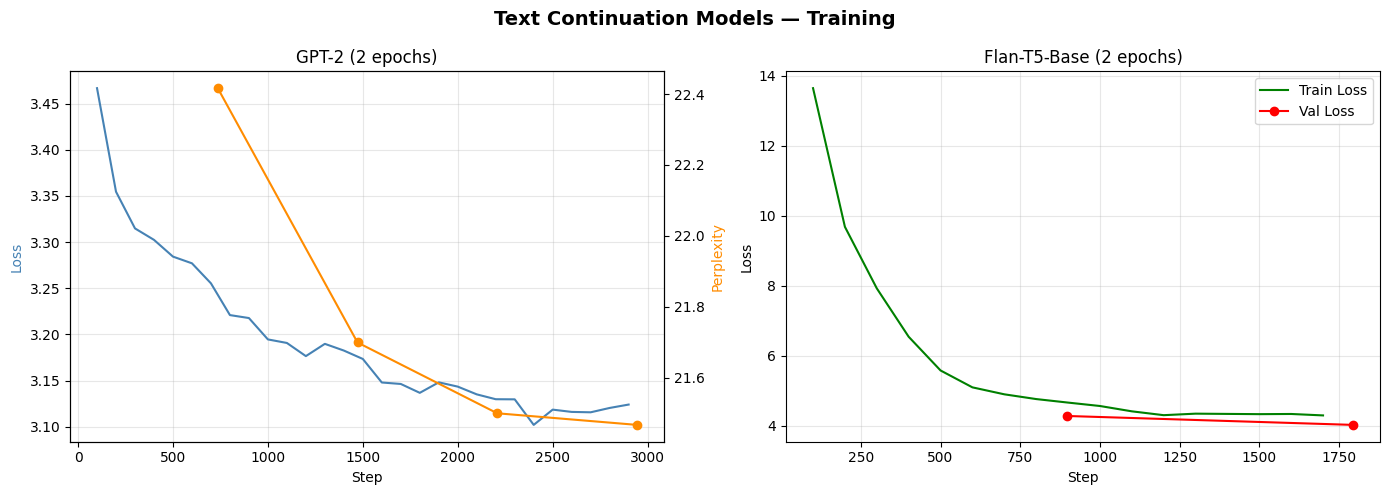

In [34]:
# ============================================================
# CELL 10: GPT-2 AND FLAN-T5 GRAPHS
# Loads from saved trainer state if Cell 8/9 were skipped
# ============================================================
import matplotlib.pyplot as plt, math, json

def load_log_history(model_dir):
    state_files = sorted(glob.glob(f"{model_dir}/checkpoint-*/trainer_state.json"))
    if not state_files:
        # try root
        root_state = os.path.join(model_dir, "trainer_state.json")
        if os.path.exists(root_state):
            with open(root_state) as f:
                return json.load(f)["log_history"]
        return None
    with open(state_files[-1]) as f:
        return json.load(f)["log_history"]

try:
    g_log = gpt2_trainer.state.log_history
except NameError:
    g_log = load_log_history(GPT2_OUT)

try:
    f_log = flan_trainer.state.log_history
except NameError:
    f_log = load_log_history(FLAN_OUT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Text Continuation Models — Training", fontsize=14, fontweight="bold")

if g_log:
    g_steps  = [e["step"] for e in g_log if "loss" in e and "eval_loss" not in e]
    g_losses = [e["loss"] for e in g_log if "loss" in e and "eval_loss" not in e]
    g_e_steps= [e["step"] for e in g_log if "eval_loss" in e]
    g_e_ppls = [math.exp(min(e["eval_loss"], 10)) for e in g_log if "eval_loss" in e]
    ax1 = axes[0]
    ax1.plot(g_steps, g_losses, color="steelblue", label="Train Loss")
    ax1b = ax1.twinx()
    ax1b.plot(g_e_steps, g_e_ppls, color="darkorange", marker="o", label="Val Perplexity")
    ax1.set_title("GPT-2 (2 epochs)")
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Loss", color="steelblue")
    ax1b.set_ylabel("Perplexity", color="darkorange")
    ax1.grid(True, alpha=0.3)

if f_log:
    f_steps  = [e["step"] for e in f_log if "loss" in e and "eval_loss" not in e]
    f_losses = [e["loss"] for e in f_log if "loss" in e and "eval_loss" not in e]
    f_e_steps= [e["step"] for e in f_log if "eval_loss" in e]
    f_e_losses=[e["eval_loss"] for e in f_log if "eval_loss" in e]
    axes[1].plot(f_steps, f_losses, color="green", label="Train Loss")
    axes[1].plot(f_e_steps, f_e_losses, color="red", marker="o", label="Val Loss")
    axes[1].set_title("Flan-T5-Base (2 epochs)")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/continuation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# ============================================================
# CHECK FLAN-T5 CHECKPOINTS
# ============================================================

import os

print("FLAN_OUT:", FLAN_OUT)
print("\nFiles:")

for root, dirs, files in os.walk(FLAN_OUT):
    level = root.replace(FLAN_OUT, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

FLAN_OUT: /kaggle/working/flan-t5-continuation

Files:
flan-t5-continuation/
  checkpoint-1794/
    tokenizer_config.json
    training_args.bin
    optimizer.pt
    trainer_state.json
    rng_state.pth
    scheduler.pt
    generation_config.json
    config.json
    model.safetensors
    scaler.pt
    tokenizer.json


In [38]:
# ============================================================
# CELL 11 — LOAD TRAINED MODELS + TEST GENERATION
# FIXED VERSION
# GPT-2 / GPT-Neo TOKENIZER FIX
# ============================================================

import os
import glob
import torch
import traceback

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ============================================================
# PATHS
# ============================================================

GPT2_OUT = "/kaggle/working/gpt2-en-continuation-v2"
NEO_OUT  = "/kaggle/working/gptneo-en-continuation"
FLAN_OUT = "/kaggle/working/flan-t5-continuation"


# ============================================================
# HELPER — FIND LATEST CHECKPOINT
# ============================================================

def find_latest_checkpoint(output_dir):

    if not os.path.exists(output_dir):
        return None

    checkpoints = glob.glob(
        os.path.join(output_dir, "checkpoint-*")
    )

    if not checkpoints:
        return None

    checkpoints = sorted(
        checkpoints,
        key=lambda x: int(os.path.basename(x).split("-")[-1])
    )

    print(f"Found {len(checkpoints)} checkpoint(s)")
    print("Latest checkpoint:", checkpoints[-1])

    return checkpoints[-1]


# ============================================================
# 1. LOAD GPT-2
# ============================================================

print("\n" + "=" * 70)
print("LOADING GPT-2")
print("=" * 70)

GPT2_PATH = find_latest_checkpoint(GPT2_OUT)

if GPT2_PATH is None:
    print("❌ GPT-2 checkpoint not found")

    gpt2_model = None
    gpt2_tokenizer = None

else:

    print("\nGPT-2 model path:")
    print(GPT2_PATH)

    # --------------------------------------------------------
    # IMPORTANT FIX:
    # DO NOT LOAD TOKENIZER FROM CHECKPOINT
    # USE ORIGINAL GPT-2 TOKENIZER
    # --------------------------------------------------------

    gpt2_tokenizer = AutoTokenizer.from_pretrained(
        "gpt2"
    )

    # GPT-2 has no pad token by default
    if gpt2_tokenizer.pad_token is None:
        gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

    gpt2_model = AutoModelForCausalLM.from_pretrained(
        GPT2_PATH
    )

    gpt2_model.config.pad_token_id = gpt2_tokenizer.pad_token_id

    gpt2_model.to(device)
    gpt2_model.eval()

    print("\nGPT-2 tokenizer:")
    print("vocab_size   :", gpt2_tokenizer.vocab_size)
    print("pad_token    :", gpt2_tokenizer.pad_token)
    print("pad_token_id :", gpt2_tokenizer.pad_token_id)
    print("eos_token    :", gpt2_tokenizer.eos_token)
    print("eos_token_id :", gpt2_tokenizer.eos_token_id)

    print("\n✅ GPT-2 loaded successfully")


# ============================================================
# 2. LOAD GPT-Neo
# ============================================================

print("\n" + "=" * 70)
print("LOADING GPT-Neo")
print("=" * 70)

NEO_PATH = find_latest_checkpoint(NEO_OUT)

if NEO_PATH is None:
    print("❌ GPT-Neo checkpoint not found")

    neo_model = None
    neo_tokenizer = None

else:

    print("\nGPT-Neo model path:")
    print(NEO_PATH)

    # --------------------------------------------------------
    # IMPORTANT FIX:
    # USE ORIGINAL GPT-Neo TOKENIZER
    # NOT CHECKPOINT TOKENIZER
    # --------------------------------------------------------

    neo_tokenizer = AutoTokenizer.from_pretrained(
        "EleutherAI/gpt-neo-125M"
    )

    # GPT-Neo also has no pad token by default
    if neo_tokenizer.pad_token is None:
        neo_tokenizer.pad_token = neo_tokenizer.eos_token

    neo_model = AutoModelForCausalLM.from_pretrained(
        NEO_PATH
    )

    neo_model.config.pad_token_id = neo_tokenizer.pad_token_id

    neo_model.to(device)
    neo_model.eval()

    print("\nGPT-Neo tokenizer:")
    print("vocab_size   :", neo_tokenizer.vocab_size)
    print("pad_token    :", neo_tokenizer.pad_token)
    print("pad_token_id :", neo_tokenizer.pad_token_id)
    print("eos_token    :", neo_tokenizer.eos_token)
    print("eos_token_id :", neo_tokenizer.eos_token_id)

    print("\n✅ GPT-Neo loaded successfully")


# ============================================================
# 3. LOAD FLAN-T5
# ============================================================

print("\n" + "=" * 70)
print("LOADING FLAN-T5")
print("=" * 70)

FLAN_PATH = find_latest_checkpoint(FLAN_OUT)

if FLAN_PATH is None:

    print("❌ FLAN-T5 checkpoint not found")

    flan_model = None
    flan_tokenizer = None

else:

    print("\nFLAN-T5 model path:")
    print(FLAN_PATH)

    flan_tokenizer = AutoTokenizer.from_pretrained(
        FLAN_PATH
    )

    flan_model = AutoModelForSeq2SeqLM.from_pretrained(
        FLAN_PATH
    )

    flan_model.to(device)
    flan_model.eval()

    print("\nFLAN-T5 tokenizer vocab size:")
    print(flan_tokenizer.vocab_size)

    print("\n✅ FLAN-T5 loaded successfully")


# ============================================================
# 4. TEST TOKENIZATION FIRST
# ============================================================

print("\n" + "=" * 70)
print("TOKENIZER TEST")
print("=" * 70)

test_prompt = "The main topic of today's presentation is"


# ------------------------------------------------------------
# GPT-2 TOKENIZER TEST
# ------------------------------------------------------------

if gpt2_tokenizer is not None:

    print("\nGPT-2 tokenization:")

    test_tokens = gpt2_tokenizer(
        test_prompt,
        return_tensors="pt"
    )

    print("Input IDs:")
    print(test_tokens["input_ids"])

    print("Shape:")
    print(test_tokens["input_ids"].shape)

    if test_tokens["input_ids"].shape[1] > 0:
        print("✅ GPT-2 tokenizer is working")
    else:
        print("❌ GPT-2 tokenizer still broken")


# ------------------------------------------------------------
# GPT-Neo TOKENIZER TEST
# ------------------------------------------------------------

if neo_tokenizer is not None:

    print("\nGPT-Neo tokenization:")

    test_tokens = neo_tokenizer(
        test_prompt,
        return_tensors="pt"
    )

    print("Input IDs:")
    print(test_tokens["input_ids"])

    print("Shape:")
    print(test_tokens["input_ids"].shape)

    if test_tokens["input_ids"].shape[1] > 0:
        print("✅ GPT-Neo tokenizer is working")
    else:
        print("❌ GPT-Neo tokenizer still broken")


# ============================================================
# 5. GENERATION FUNCTION — GPT-2
# ============================================================

def generate_gpt2(prompt, max_new_tokens=40):

    if gpt2_model is None or gpt2_tokenizer is None:
        return "GPT-2 not available"

    inputs = gpt2_tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    if input_ids.shape[1] == 0:
        return "GPT-2 tokenizer produced empty input"

    with torch.no_grad():

        output = gpt2_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=gpt2_tokenizer.pad_token_id,
            eos_token_id=gpt2_tokenizer.eos_token_id
        )

    return gpt2_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )


# ============================================================
# 6. GENERATION FUNCTION — GPT-Neo
# ============================================================

def generate_neo(prompt, max_new_tokens=40):

    if neo_model is None or neo_tokenizer is None:
        return "GPT-Neo not available"

    inputs = neo_tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    if input_ids.shape[1] == 0:
        return "GPT-Neo tokenizer produced empty input"

    with torch.no_grad():

        output = neo_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=neo_tokenizer.pad_token_id,
            eos_token_id=neo_tokenizer.eos_token_id
        )

    return neo_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )


# ============================================================
# 7. GENERATION FUNCTION — FLAN-T5
# ============================================================

def generate_flan(prompt, max_new_tokens=40):

    if flan_model is None or flan_tokenizer is None:
        return "FLAN-T5 not available"

    inputs = flan_tokenizer(
        "continue: " + prompt,
        return_tensors="pt",
        truncation=True
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():

        output = flan_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True
        )

    return flan_tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )


# ============================================================
# 8. TEST ALL MODELS
# ============================================================

print("\n" + "=" * 70)
print("MODEL GENERATION TEST")
print("=" * 70)

test_prompts = [
    "The main topic of today's presentation is",
    "Artificial intelligence is becoming",
    "The history of science shows that",
    "In modern society, technology"
]


# ============================================================
# GPT-2 TEST
# ============================================================

print("\n" + "-" * 70)
print("GPT-2 GENERATION")
print("-" * 70)

for i, prompt in enumerate(test_prompts, 1):

    print(f"\nTest {i}:")
    print("Prompt :", prompt)

    try:

        result = generate_gpt2(
            prompt,
            max_new_tokens=40
        )

        print("Output :", result)

    except Exception as e:

        print("❌ GPT-2 generation failed")
        print("Error:", str(e))

        traceback.print_exc()


# ============================================================
# GPT-Neo TEST
# ============================================================

print("\n" + "-" * 70)
print("GPT-Neo GENERATION")
print("-" * 70)

for i, prompt in enumerate(test_prompts, 1):

    print(f"\nTest {i}:")
    print("Prompt :", prompt)

    try:

        result = generate_neo(
            prompt,
            max_new_tokens=40
        )

        print("Output :", result)

    except Exception as e:

        print("❌ GPT-Neo generation failed")
        print("Error:", str(e))

        traceback.print_exc()


# ============================================================
# FLAN-T5 TEST
# ============================================================

print("\n" + "-" * 70)
print("FLAN-T5 GENERATION")
print("-" * 70)

for i, prompt in enumerate(test_prompts, 1):

    print(f"\nTest {i}:")
    print("Prompt :", prompt)

    try:

        result = generate_flan(
            prompt,
            max_new_tokens=40
        )

        print("Output :", result)

    except Exception as e:

        print("❌ FLAN-T5 generation failed")
        print("Error:", str(e))

        traceback.print_exc()


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL STATUS")
print("=" * 70)

print(
    "GPT-2     :",
    "AVAILABLE" if gpt2_model is not None else "NOT AVAILABLE"
)

print(
    "GPT-Neo   :",
    "AVAILABLE" if neo_model is not None else "NOT AVAILABLE"
)

print(
    "FLAN-T5   :",
    "AVAILABLE" if flan_model is not None else "NOT AVAILABLE"
)

print("\n✅ Cell 11 completed.")

Device: cuda

LOADING GPT-2
Found 2 checkpoint(s)
Latest checkpoint: /kaggle/working/gpt2-en-continuation-v2/checkpoint-2944

GPT-2 model path:
/kaggle/working/gpt2-en-continuation-v2/checkpoint-2944


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


GPT-2 tokenizer:
vocab_size   : 50257
pad_token    : <|endoftext|>
pad_token_id : 50256
eos_token    : <|endoftext|>
eos_token_id : 50256

✅ GPT-2 loaded successfully

LOADING GPT-Neo
Found 2 checkpoint(s)
Latest checkpoint: /kaggle/working/gptneo-en-continuation/checkpoint-5884

GPT-Neo model path:
/kaggle/working/gptneo-en-continuation/checkpoint-5884


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]


GPT-Neo tokenizer:
vocab_size   : 50257
pad_token    : <|endoftext|>
pad_token_id : 50256
eos_token    : <|endoftext|>
eos_token_id : 50256

✅ GPT-Neo loaded successfully

LOADING FLAN-T5
Found 1 checkpoint(s)
Latest checkpoint: /kaggle/working/flan-t5-continuation/checkpoint-1794

FLAN-T5 model path:
/kaggle/working/flan-t5-continuation/checkpoint-1794


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



FLAN-T5 tokenizer vocab size:
32100

✅ FLAN-T5 loaded successfully

TOKENIZER TEST

GPT-2 tokenization:
Input IDs:
tensor([[  464,  1388,  7243,   286,  1909,   338, 10470,   318]])
Shape:
torch.Size([1, 8])
✅ GPT-2 tokenizer is working

GPT-Neo tokenization:
Input IDs:
tensor([[  464,  1388,  7243,   286,  1909,   338, 10470,   318]])
Shape:
torch.Size([1, 8])
✅ GPT-Neo tokenizer is working

MODEL GENERATION TEST

----------------------------------------------------------------------
GPT-2 GENERATION
----------------------------------------------------------------------

Test 1:
Prompt : The main topic of today's presentation is
Output : The main topic of today's presentation is the economic model of the economy.  In the case of agriculture, the main topic of the discussion is agriculture with respect to the value of commodities and the importance of resource extraction. 

In

Test 2:
Prompt : Artificial intelligence is becoming
Output : Artificial intelligence is becoming increasing

In [39]:
# ============================================================
# CELL 12: INTEGRATION PIPELINE — WHISPER + FLAN-T5
# ============================================================

import os
import glob
import torch
import torchaudio

from peft import PeftModel
from transformers import (
    WhisperForConditionalGeneration,
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

# ============================================================
# LOAD WHISPER
# ============================================================

print("Loading Whisper...")

base_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME
)

ft_model = PeftModel.from_pretrained(
    base_model,
    best_ckpt
).to(device)

ft_model.eval()

print("Whisper loaded successfully.")

# ============================================================
# LOAD FLAN-T5
# ============================================================

FLAN_MODEL_PATH = os.path.join(
    FLAN_OUT,
    "checkpoint-1794"
)

print("Loading Flan-T5 from:")
print(FLAN_MODEL_PATH)

flan_tok = AutoTokenizer.from_pretrained(
    FLAN_MODEL_PATH
)

flan_model = AutoModelForSeq2SeqLM.from_pretrained(
    FLAN_MODEL_PATH
).to(device)

flan_model.eval()

print("Flan-T5 loaded successfully.")

# ============================================================
# WHISPER TRANSCRIPTION
# ============================================================

def transcribe_chunk(wav_path):

    waveform, sr = torchaudio.load(wav_path)

    # Convert stereo → mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to Whisper's expected 16 kHz
    if sr != 16000:
        waveform = torchaudio.functional.resample(
            waveform,
            sr,
            16000
        )

    # Extract Whisper features
    feats = processor.feature_extractor(
        waveform.squeeze().numpy(),
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features.to(device)

    # Generate transcription
    with torch.no_grad():

        ids = ft_model.generate(
            input_features=feats
        )

    transcript = processor.tokenizer.decode(
        ids[0],
        skip_special_tokens=True
    )

    return transcript.strip()

# ============================================================
# FLAN-T5 CONTINUATION
# ============================================================

def suggest_continuation(transcript):

    prompt = "continue: " + transcript

    inputs = flan_tok(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(device)

    with torch.no_grad():

        output_ids = flan_model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )

    suggestion = flan_tok.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return suggestion.strip()

# ============================================================
# TEST INTEGRATION
# ============================================================

wav_files = glob.glob(
    os.path.join(CLIPS_DIR, "*.wav")
)

if not wav_files:
    raise FileNotFoundError(
        f"No .wav files found in {CLIPS_DIR}"
    )

sample_wav = wav_files[0]

print("\nTesting on:")
print(sample_wav)

# Whisper
transcript = transcribe_chunk(sample_wav)

# Flan-T5
suggestion = suggest_continuation(transcript)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("INTEGRATION TEST RESULT")
print("=" * 60)

print(f"TRANSCRIPT   : {transcript}")
print(f"SUGGESTION   : {suggestion}")

print("=" * 60)

Loading Whisper...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper loaded successfully.
Loading Flan-T5 from:
/kaggle/working/flan-t5-continuation/checkpoint-1794


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Flan-T5 loaded successfully.

Testing on:
/kaggle/input/datasets/junaedkhandakar/librispeech-clean-en/librispeech/clips/5808-54425-0039.wav

INTEGRATION TEST RESULT
TRANSCRIPT   : oh you have well don't handle it carelessly it might go off and sadness arose the reporter sat thinking for a time and then followed him leaving joe in a drunken sleep
SUGGESTION   : He was a tad nat-sassing woman with a drety to the resusus, and he was


In [40]:
# ============================================================
# CELL 13: SAVE ALL FINAL MODELS AS ONE ZIP
# ============================================================
# Includes:
#   1. Whisper
#   2. GPT-2
#   3. GPT-Neo 125M (GPT-3-style)
#   4. FLAN-T5
#   5. Training graphs
# ============================================================

import os
import shutil
import glob
from pathlib import Path
from IPython.display import display, FileLink

from transformers import AutoTokenizer


# ============================================================
# PATHS
# ============================================================

STAGING_DIR = Path(
    "/kaggle/working/final_model_output"
)

GPT2_OUT = Path(
    "/kaggle/working/gpt2-en-continuation-v2"
)

NEO_OUT = Path(
    "/kaggle/working/gptneo-en-continuation"
)

FLAN_OUT = Path(
    "/kaggle/working/flan-t5-continuation"
)


# ============================================================
# REMOVE OLD STAGING DIRECTORY
# ============================================================

if STAGING_DIR.exists():
    print("Removing previous final_model_output...")
    shutil.rmtree(STAGING_DIR)

STAGING_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# HELPER FUNCTION
# ============================================================

def find_latest_checkpoint(output_dir):

    output_dir = Path(output_dir)

    if not output_dir.exists():
        return None

    checkpoints = list(
        output_dir.glob("checkpoint-*")
    )

    if not checkpoints:
        return None

    checkpoints = sorted(
        checkpoints,
        key=lambda x: int(
            x.name.split("-")[-1]
        )
    )

    return checkpoints[-1]


def copy_checkpoint(
    source_checkpoint,
    destination_folder,
    skip_training_files=False
):

    source_checkpoint = Path(
        source_checkpoint
    )

    destination_folder = Path(
        destination_folder
    )

    destination_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    skip_files = {
        "optimizer.pt",
        "scaler.pt",
        "rng_state.pth",
        "scheduler.pt",
        "trainer_state.json",
        "training_args.bin"
    }

    for item in source_checkpoint.iterdir():

        if (
            skip_training_files
            and item.name in skip_files
        ):
            continue

        destination = (
            destination_folder / item.name
        )

        if item.is_dir():

            shutil.copytree(
                item,
                destination
            )

        else:

            shutil.copy2(
                item,
                destination
            )


# ============================================================
# 1. WHISPER — BEST LORA CHECKPOINT
# ============================================================

print("\n" + "=" * 70)
print("1. PREPARING WHISPER")
print("=" * 70)

STAGING_WHISPER = (
    STAGING_DIR / "whisper-en-lora"
)

STAGING_WHISPER.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# best_ckpt must already exist from Whisper training
# ------------------------------------------------------------

if "best_ckpt" not in globals():

    raise NameError(
        "best_ckpt variable was not found. "
        "Please run the Whisper training/evaluation cell first."
    )

best_ckpt_path = Path(best_ckpt)

if not best_ckpt_path.exists():

    raise FileNotFoundError(
        f"Whisper checkpoint not found: {best_ckpt_path}"
    )

copy_checkpoint(
    best_ckpt_path,
    STAGING_WHISPER,
    skip_training_files=False
)

print("Whisper checkpoint copied:")
print(best_ckpt_path)


# ============================================================
# 2. GPT-2 — LATEST FINAL CHECKPOINT
# ============================================================

print("\n" + "=" * 70)
print("2. PREPARING GPT-2")
print("=" * 70)

GPT2_FINAL_CKPT = find_latest_checkpoint(
    GPT2_OUT
)

if GPT2_FINAL_CKPT is None:

    raise FileNotFoundError(
        f"No GPT-2 checkpoint found in: {GPT2_OUT}"
    )

print("GPT-2 checkpoint selected:")
print(GPT2_FINAL_CKPT)


STAGING_GPT2 = (
    STAGING_DIR / "gpt2-en-continuation"
)

STAGING_GPT2.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Copy trained GPT-2 checkpoint
# ------------------------------------------------------------

copy_checkpoint(
    GPT2_FINAL_CKPT,
    STAGING_GPT2,
    skip_training_files=True
)

# ------------------------------------------------------------
# IMPORTANT:
# Save ORIGINAL GPT-2 tokenizer
# because checkpoint tokenizer was broken
# ------------------------------------------------------------

print("\nSaving original GPT-2 tokenizer...")

gpt2_final_tokenizer = AutoTokenizer.from_pretrained(
    "gpt2"
)

if gpt2_final_tokenizer.pad_token is None:

    gpt2_final_tokenizer.pad_token = (
        gpt2_final_tokenizer.eos_token
    )

gpt2_final_tokenizer.save_pretrained(
    STAGING_GPT2
)

print("GPT-2 tokenizer saved successfully.")

print("\nGPT-2 final folder:")
print(STAGING_GPT2)


# ============================================================
# 3. GPT-Neo 125M — GPT-3-STYLE MODEL
# ============================================================

print("\n" + "=" * 70)
print("3. PREPARING GPT-Neo 125M")
print("=" * 70)

NEO_FINAL_CKPT = find_latest_checkpoint(
    NEO_OUT
)

if NEO_FINAL_CKPT is None:

    raise FileNotFoundError(
        f"No GPT-Neo checkpoint found in: {NEO_OUT}"
    )

print("GPT-Neo checkpoint selected:")
print(NEO_FINAL_CKPT)


STAGING_NEO = (
    STAGING_DIR / "gptneo-125m-gpt3-style"
)

STAGING_NEO.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Copy trained GPT-Neo checkpoint
# ------------------------------------------------------------

copy_checkpoint(
    NEO_FINAL_CKPT,
    STAGING_NEO,
    skip_training_files=True
)

# ------------------------------------------------------------
# IMPORTANT:
# Save ORIGINAL GPT-Neo tokenizer
# because checkpoint tokenizer was broken
# ------------------------------------------------------------

print("\nSaving original GPT-Neo tokenizer...")

neo_final_tokenizer = AutoTokenizer.from_pretrained(
    "EleutherAI/gpt-neo-125M"
)

if neo_final_tokenizer.pad_token is None:

    neo_final_tokenizer.pad_token = (
        neo_final_tokenizer.eos_token
    )

neo_final_tokenizer.save_pretrained(
    STAGING_NEO
)

print("GPT-Neo tokenizer saved successfully.")

print("\nGPT-Neo final folder:")
print(STAGING_NEO)


# ============================================================
# 4. FLAN-T5 — LATEST FINAL CHECKPOINT
# ============================================================

print("\n" + "=" * 70)
print("4. PREPARING FLAN-T5")
print("=" * 70)

FLAN_FINAL_CKPT = find_latest_checkpoint(
    FLAN_OUT
)

if FLAN_FINAL_CKPT is None:

    raise FileNotFoundError(
        f"No FLAN-T5 checkpoint found in: {FLAN_OUT}"
    )

print("FLAN-T5 checkpoint selected:")
print(FLAN_FINAL_CKPT)


STAGING_FLAN = (
    STAGING_DIR / "flan-t5-continuation"
)

STAGING_FLAN.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Copy FLAN-T5 checkpoint
# ------------------------------------------------------------

copy_checkpoint(
    FLAN_FINAL_CKPT,
    STAGING_FLAN,
    skip_training_files=True
)

print("\nFLAN-T5 final folder:")
print(STAGING_FLAN)


# ============================================================
# 5. COPY TRAINING GRAPHS
# ============================================================

print("\n" + "=" * 70)
print("5. COPYING TRAINING GRAPHS")
print("=" * 70)

GRAPH_FILES = [
    "training_curves.png",
    "continuation_curves.png"
]

for graph in GRAPH_FILES:

    source = (
        Path("/kaggle/working") / graph
    )

    if source.exists():

        destination = (
            STAGING_DIR / graph
        )

        shutil.copy2(
            source,
            destination
        )

        print(f"Copied: {graph}")

    else:

        print(f"Not found: {graph}")


# ============================================================
# 6. CREATE MODEL INFORMATION FILE
# ============================================================

INFO_FILE = (
    STAGING_DIR / "MODEL_INFO.txt"
)

with open(
    INFO_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "FINAL ENGLISH LANGUAGE MODEL OUTPUT\n"
    )

    f.write(
        "===================================\n\n"
    )

    f.write(
        "1. Whisper\n"
    )

    f.write(
        "   Best LoRA checkpoint\n\n"
    )

    f.write(
        "2. GPT-2\n"
    )

    f.write(
        "   Fine-tuned GPT-2 language model\n"
    )

    f.write(
        "   Original GPT-2 tokenizer included\n\n"
    )

    f.write(
        "3. GPT-Neo 125M\n"
    )

    f.write(
        "   GPT-3-style open-source language model\n"
    )

    f.write(
        "   Original GPT-Neo tokenizer included\n\n"
    )

    f.write(
        "4. FLAN-T5\n"
    )

    f.write(
        "   Fine-tuned FLAN-T5 continuation model\n\n"
    )

    f.write(
        "Training graphs are included if available.\n"
    )


print("\nCreated:")
print(INFO_FILE)


# ============================================================
# 7. SHOW FINAL DIRECTORY CONTENTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL DIRECTORY")
print("=" * 70)

for root, dirs, files in os.walk(
    STAGING_DIR
):

    level = (
        root.replace(
            str(STAGING_DIR),
            ""
        ).count(os.sep)
    )

    indent = "  " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    for file in files:

        file_path = (
            Path(root) / file
        )

        size_mb = (
            file_path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"{indent}  {file} "
            f"({size_mb:.2f} MB)"
        )


# ============================================================
# 8. CREATE FINAL ZIP
# ============================================================

print("\n" + "=" * 70)
print("CREATING FINAL ZIP")
print("=" * 70)

ZIP_BASE = Path(
    "/kaggle/working/final_model_output"
)

ZIP_PATH = Path(
    str(ZIP_BASE) + ".zip"
)

if ZIP_PATH.exists():

    print("Removing previous ZIP...")

    ZIP_PATH.unlink()


shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    "/kaggle/working",
    "final_model_output"
)


# ============================================================
# 9. FINAL ZIP SIZE
# ============================================================

zip_size_mb = (
    ZIP_PATH.stat().st_size
    / (1024 ** 2)
)

print("\n" + "=" * 70)
print(
    f"FINAL ZIP SIZE: {zip_size_mb:.2f} MB"
)
print("=" * 70)


# ============================================================
# 10. DOWNLOAD LINK
# ============================================================

display(
    FileLink(
        str(ZIP_PATH),
        result_html_prefix="Download: "
    )
)


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL ZIP CONTENTS")
print("=" * 70)

print("""
1. whisper-en-lora
   └── Best Whisper LoRA checkpoint

2. gpt2-en-continuation
   └── Fine-tuned GPT-2
   └── Original GPT-2 tokenizer included

3. gptneo-125m-gpt3-style
   └── Fine-tuned GPT-Neo 125M
   └── GPT-3-style open-source model
   └── Original GPT-Neo tokenizer included

4. flan-t5-continuation
   └── Fine-tuned FLAN-T5

5. MODEL_INFO.txt

6. Training graphs
   └── If available
""")

print(
    "\nUpload this ZIP as a Kaggle Dataset named:"
)

print(
    "'english-model-output'"
)

print("\n✅ FINAL MODEL PACKAGING COMPLETE")


1. PREPARING WHISPER
Whisper checkpoint copied:
/kaggle/working/whisper-en-lora/checkpoint-700

2. PREPARING GPT-2
GPT-2 checkpoint selected:
/kaggle/working/gpt2-en-continuation-v2/checkpoint-2944

Saving original GPT-2 tokenizer...
GPT-2 tokenizer saved successfully.

GPT-2 final folder:
/kaggle/working/final_model_output/gpt2-en-continuation

3. PREPARING GPT-Neo 125M
GPT-Neo checkpoint selected:
/kaggle/working/gptneo-en-continuation/checkpoint-5884

Saving original GPT-Neo tokenizer...
GPT-Neo tokenizer saved successfully.

GPT-Neo final folder:
/kaggle/working/final_model_output/gptneo-125m-gpt3-style

4. PREPARING FLAN-T5
FLAN-T5 checkpoint selected:
/kaggle/working/flan-t5-continuation/checkpoint-1794

FLAN-T5 final folder:
/kaggle/working/final_model_output/flan-t5-continuation

5. COPYING TRAINING GRAPHS
Copied: training_curves.png
Copied: continuation_curves.png

Created:
/kaggle/working/final_model_output/MODEL_INFO.txt

FINAL MODEL DIRECTORY
final_model_output/
  continua

/kaggle/working/final_model_output.zip


FINAL ZIP CONTENTS

1. whisper-en-lora
   └── Best Whisper LoRA checkpoint

2. gpt2-en-continuation
   └── Fine-tuned GPT-2
   └── Original GPT-2 tokenizer included

3. gptneo-125m-gpt3-style
   └── Fine-tuned GPT-Neo 125M
   └── GPT-3-style open-source model
   └── Original GPT-Neo tokenizer included

4. flan-t5-continuation
   └── Fine-tuned FLAN-T5

5. MODEL_INFO.txt

6. Training graphs
   └── If available


Upload this ZIP as a Kaggle Dataset named:
'english-model-output'

✅ FINAL MODEL PACKAGING COMPLETE


In [41]:
# ============================================================
# CELL 13: OPTIMIZE ALL MODELS TO FP16 + CREATE ZIP
# ============================================================
#
# Includes:
#   1. GPT-2 FP16
#   2. GPT-Neo 125M FP16 (GPT-3-style)
#   3. FLAN-T5 FP16
#   4. Whisper LoRA
#
# Uses latest available checkpoints automatically.
# ============================================================

import os
import shutil
from pathlib import Path

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM
)

from IPython.display import display, FileLink


# ============================================================
# PATHS
# ============================================================

OPTIMIZED_DIR = Path(
    "/kaggle/working/optimized_model_output"
)

if OPTIMIZED_DIR.exists():
    shutil.rmtree(OPTIMIZED_DIR)

OPTIMIZED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# MODEL OUTPUT PATHS
# ============================================================

GPT2_OUT = Path(
    "/kaggle/working/gpt2-en-continuation-v2"
)

NEO_OUT = Path(
    "/kaggle/working/gptneo-en-continuation"
)

FLAN_OUT = Path(
    "/kaggle/working/flan-t5-continuation"
)


# ============================================================
# HELPER — FIND LATEST CHECKPOINT
# ============================================================

def find_latest_checkpoint(output_dir):

    output_dir = Path(output_dir)

    if not output_dir.exists():
        return None

    checkpoints = list(
        output_dir.glob("checkpoint-*")
    )

    if not checkpoints:
        return None

    checkpoints = sorted(
        checkpoints,
        key=lambda x: int(
            x.name.split("-")[-1]
        )
    )

    return checkpoints[-1]


# ============================================================
# FIND FINAL CHECKPOINTS
# ============================================================

GPT2_FINAL = find_latest_checkpoint(
    GPT2_OUT
)

NEO_FINAL = find_latest_checkpoint(
    NEO_OUT
)

FLAN_FINAL = find_latest_checkpoint(
    FLAN_OUT
)


print("=" * 70)
print("FINAL CHECKPOINTS SELECTED")
print("=" * 70)

print(
    "GPT-2    :",
    GPT2_FINAL
)

print(
    "GPT-Neo  :",
    NEO_FINAL
)

print(
    "FLAN-T5  :",
    FLAN_FINAL
)


# ============================================================
# VALIDATE CHECKPOINTS
# ============================================================

if GPT2_FINAL is None:
    raise FileNotFoundError(
        f"GPT-2 checkpoint not found in {GPT2_OUT}"
    )

if NEO_FINAL is None:
    raise FileNotFoundError(
        f"GPT-Neo checkpoint not found in {NEO_OUT}"
    )

if FLAN_FINAL is None:
    raise FileNotFoundError(
        f"FLAN-T5 checkpoint not found in {FLAN_OUT}"
    )


# ============================================================
# 1. GPT-2 → FP16
# ============================================================

print("\n" + "=" * 70)
print("1. CONVERTING GPT-2 TO FP16")
print("=" * 70)

GPT2_FP16_DIR = (
    OPTIMIZED_DIR / "gpt2-en-continuation"
)

GPT2_FP16_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# IMPORTANT:
# Use ORIGINAL GPT-2 tokenizer
# because checkpoint tokenizer was broken.
# ------------------------------------------------------------

print("\nLoading original GPT-2 tokenizer...")

gpt2_tokenizer = AutoTokenizer.from_pretrained(
    "gpt2"
)

if gpt2_tokenizer.pad_token is None:
    gpt2_tokenizer.pad_token = (
        gpt2_tokenizer.eos_token
    )


print(
    "GPT-2 tokenizer vocab size:",
    gpt2_tokenizer.vocab_size
)


# ------------------------------------------------------------
# Load trained GPT-2 checkpoint
# ------------------------------------------------------------

print("\nLoading trained GPT-2 model...")

gpt2_model = AutoModelForCausalLM.from_pretrained(
    GPT2_FINAL,
    torch_dtype=torch.float32
)


# ------------------------------------------------------------
# Set correct pad token
# ------------------------------------------------------------

gpt2_model.config.pad_token_id = (
    gpt2_tokenizer.pad_token_id
)


# ------------------------------------------------------------
# FP32 → FP16
# ------------------------------------------------------------

print("Converting GPT-2 FP32 → FP16...")

gpt2_model = gpt2_model.half()


# ------------------------------------------------------------
# Save inference-only model
# ------------------------------------------------------------

gpt2_model.save_pretrained(
    GPT2_FP16_DIR,
    safe_serialization=True,
    max_shard_size="5GB"
)

gpt2_tokenizer.save_pretrained(
    GPT2_FP16_DIR
)


print("\n✅ GPT-2 FP16 saved.")


# ------------------------------------------------------------
# Free memory
# ------------------------------------------------------------

del gpt2_model
del gpt2_tokenizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 2. GPT-Neo 125M → FP16
# ============================================================

print("\n" + "=" * 70)
print("2. CONVERTING GPT-Neo 125M TO FP16")
print("=" * 70)

NEO_FP16_DIR = (
    OPTIMIZED_DIR /
    "gptneo-125m-gpt3-style"
)

NEO_FP16_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Original GPT-Neo tokenizer
# ------------------------------------------------------------

print("\nLoading original GPT-Neo tokenizer...")

neo_tokenizer = AutoTokenizer.from_pretrained(
    "EleutherAI/gpt-neo-125M"
)

if neo_tokenizer.pad_token is None:
    neo_tokenizer.pad_token = (
        neo_tokenizer.eos_token
    )


print(
    "GPT-Neo tokenizer vocab size:",
    neo_tokenizer.vocab_size
)


# ------------------------------------------------------------
# Load trained GPT-Neo
# ------------------------------------------------------------

print("\nLoading trained GPT-Neo model...")

neo_model = AutoModelForCausalLM.from_pretrained(
    NEO_FINAL,
    torch_dtype=torch.float32
)


# ------------------------------------------------------------
# Set correct pad token
# ------------------------------------------------------------

neo_model.config.pad_token_id = (
    neo_tokenizer.pad_token_id
)


# ------------------------------------------------------------
# FP32 → FP16
# ------------------------------------------------------------

print("Converting GPT-Neo FP32 → FP16...")

neo_model = neo_model.half()


# ------------------------------------------------------------
# Save inference-only model
# ------------------------------------------------------------

neo_model.save_pretrained(
    NEO_FP16_DIR,
    safe_serialization=True,
    max_shard_size="5GB"
)

neo_tokenizer.save_pretrained(
    NEO_FP16_DIR
)


print("\n✅ GPT-Neo FP16 saved.")


# ------------------------------------------------------------
# Free memory
# ------------------------------------------------------------

del neo_model
del neo_tokenizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 3. FLAN-T5 → FP16
# ============================================================

print("\n" + "=" * 70)
print("3. CONVERTING FLAN-T5 TO FP16")
print("=" * 70)

FLAN_FP16_DIR = (
    OPTIMIZED_DIR / "flan-t5-continuation"
)

FLAN_FP16_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Load FLAN-T5 tokenizer
# ------------------------------------------------------------

print("\nLoading FLAN-T5 tokenizer...")

flan_tokenizer = AutoTokenizer.from_pretrained(
    FLAN_FINAL
)


# ------------------------------------------------------------
# Load trained FLAN-T5
# ------------------------------------------------------------

print("\nLoading trained FLAN-T5 model...")

flan_model = AutoModelForSeq2SeqLM.from_pretrained(
    FLAN_FINAL,
    torch_dtype=torch.float32
)


# ------------------------------------------------------------
# Prevent tied-weight warning
# ------------------------------------------------------------

flan_model.config.tie_word_embeddings = False


# ------------------------------------------------------------
# FP32 → FP16
# ------------------------------------------------------------

print("Converting FLAN-T5 FP32 → FP16...")

flan_model = flan_model.half()


# ------------------------------------------------------------
# Save inference-only model
# ------------------------------------------------------------

flan_model.save_pretrained(
    FLAN_FP16_DIR,
    safe_serialization=True,
    max_shard_size="5GB"
)

flan_tokenizer.save_pretrained(
    FLAN_FP16_DIR
)


print("\n✅ FLAN-T5 FP16 saved.")


# ------------------------------------------------------------
# Free memory
# ------------------------------------------------------------

del flan_model
del flan_tokenizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 4. COPY WHISPER LoRA
# ============================================================

print("\n" + "=" * 70)
print("4. COPYING WHISPER LoRA")
print("=" * 70)


if "best_ckpt" not in globals():

    raise NameError(
        "best_ckpt variable was not found. "
        "Please run the Whisper training/evaluation cell first."
    )


WHISPER_SOURCE = Path(
    best_ckpt
)

if not WHISPER_SOURCE.exists():

    raise FileNotFoundError(
        f"Whisper checkpoint not found: {WHISPER_SOURCE}"
    )


WHISPER_DIR = (
    OPTIMIZED_DIR / "whisper-en-lora"
)

WHISPER_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Training-state files that are NOT needed for inference
# ------------------------------------------------------------

SKIP_FILES = {
    "optimizer.pt",
    "optimizer.bin",
    "scheduler.pt",
    "scaler.pt",
    "rng_state.pth",
    "trainer_state.json",
    "training_args.bin"
}


for item in WHISPER_SOURCE.iterdir():

    if item.name in SKIP_FILES:
        continue

    destination = (
        WHISPER_DIR / item.name
    )

    if item.is_dir():

        shutil.copytree(
            item,
            destination
        )

    else:

        shutil.copy2(
            item,
            destination
        )


print("✅ Whisper LoRA copied.")


# ============================================================
# 5. CREATE MODEL INFORMATION FILE
# ============================================================

INFO_FILE = (
    OPTIMIZED_DIR / "MODEL_INFO.txt"
)

with open(
    INFO_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "OPTIMIZED FINAL MODEL OUTPUT\n"
    )

    f.write(
        "============================\n\n"
    )

    f.write(
        "1. GPT-2\n"
    )

    f.write(
        "   Fine-tuned GPT-2\n"
    )

    f.write(
        "   FP16 inference model\n"
    )

    f.write(
        "   Original GPT-2 tokenizer included\n\n"
    )

    f.write(
        "2. GPT-Neo 125M\n"
    )

    f.write(
        "   Fine-tuned GPT-Neo 125M\n"
    )

    f.write(
        "   GPT-3-style open-source model\n"
    )

    f.write(
        "   FP16 inference model\n"
    )

    f.write(
        "   Original GPT-Neo tokenizer included\n\n"
    )

    f.write(
        "3. FLAN-T5\n"
    )

    f.write(
        "   Fine-tuned FLAN-T5\n"
    )

    f.write(
        "   FP16 inference model\n\n"
    )

    f.write(
        "4. Whisper\n"
    )

    f.write(
        "   Best LoRA inference checkpoint\n\n"
    )

    f.write(
        "Training-state files such as optimizer, "
        "scheduler and RNG files are excluded.\n"
    )


print("\nCreated:")
print(INFO_FILE)


# ============================================================
# 6. SHOW OPTIMIZED MODEL SIZES
# ============================================================

print("\n" + "=" * 70)
print("OPTIMIZED MODEL SIZES")
print("=" * 70)

total_model_size = 0.0

for root, dirs, files in os.walk(
    OPTIMIZED_DIR
):

    for file in files:

        path = Path(root) / file

        if path.suffix.lower() in [
            ".safetensors",
            ".bin"
        ]:

            size_mb = (
                path.stat().st_size
                / (1024 ** 2)
            )

            total_model_size += size_mb

            print(
                f"{path.relative_to(OPTIMIZED_DIR)}"
                f"  →  {size_mb:.2f} MB"
            )


print(
    f"\nTotal model weight size: "
    f"{total_model_size:.2f} MB"
)


# ============================================================
# 7. CREATE ZIP
# ============================================================

print("\n" + "=" * 70)
print("CREATING FINAL FP16 ZIP")
print("=" * 70)


ZIP_BASE = Path(
    "/kaggle/working/optimized_model_output"
)

ZIP_PATH = Path(
    str(ZIP_BASE) + ".zip"
)


if ZIP_PATH.exists():

    print("Removing previous ZIP...")

    ZIP_PATH.unlink()


shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    "/kaggle/working",
    "optimized_model_output"
)


# ============================================================
# 8. FINAL RESULT
# ============================================================

zip_size_mb = (
    ZIP_PATH.stat().st_size
    / (1024 ** 2)
)


print("\n" + "=" * 70)
print(
    f"FINAL FP16 ZIP SIZE: "
    f"{zip_size_mb:.2f} MB"
)
print("=" * 70)


display(
    FileLink(
        str(ZIP_PATH),
        result_html_prefix=
        "Download optimized model: "
    )
)


# ============================================================
# 9. FINAL CONTENT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL ZIP CONTENTS")
print("=" * 70)

print("""
1. gpt2-en-continuation
   ├── Fine-tuned GPT-2
   ├── FP16 weights
   └── Original GPT-2 tokenizer

2. gptneo-125m-gpt3-style
   ├── Fine-tuned GPT-Neo 125M
   ├── FP16 weights
   └── Original GPT-Neo tokenizer

3. flan-t5-continuation
   ├── Fine-tuned FLAN-T5
   └── FP16 weights

4. whisper-en-lora
   └── Best Whisper LoRA checkpoint

5. MODEL_INFO.txt

Training-state files are NOT included.
""")

print(
    "\n✅ ALL MODELS OPTIMIZED AND PACKAGED SUCCESSFULLY."
)

FINAL CHECKPOINTS SELECTED
GPT-2    : /kaggle/working/gpt2-en-continuation-v2/checkpoint-2944
GPT-Neo  : /kaggle/working/gptneo-en-continuation/checkpoint-5884
FLAN-T5  : /kaggle/working/flan-t5-continuation/checkpoint-1794

1. CONVERTING GPT-2 TO FP16

Loading original GPT-2 tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


GPT-2 tokenizer vocab size: 50257

Loading trained GPT-2 model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Converting GPT-2 FP32 → FP16...


...

Converting FLAN-T5 FP32 → FP16...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ FLAN-T5 FP16 saved.

4. COPYING WHISPER LoRA
✅ Whisper LoRA copied.

Created:
/kaggle/working/optimized_model_output/MODEL_INFO.txt

OPTIMIZED MODEL SIZES
whisper-en-lora/adapter_model.safetensors  →  6.77 MB
gpt2-en-continuation/model.safetensors  →  237.36 MB
flan-t5-continuation/model.safetensors  →  472.25 MB
gptneo-125m-gpt3-style/model.safetensors  →  238.81 MB

Total model weight size: 955.20 MB

CREATING FINAL FP16 ZIP

FINAL FP16 ZIP SIZE: 884.44 MB


/kaggle/working/optimized_model_output.zip


FINAL ZIP CONTENTS

1. gpt2-en-continuation
   ├── Fine-tuned GPT-2
   ├── FP16 weights
   └── Original GPT-2 tokenizer

2. gptneo-125m-gpt3-style
   ├── Fine-tuned GPT-Neo 125M
   ├── FP16 weights
   └── Original GPT-Neo tokenizer

3. flan-t5-continuation
   ├── Fine-tuned FLAN-T5
   └── FP16 weights

4. whisper-en-lora
   └── Best Whisper LoRA checkpoint

5. MODEL_INFO.txt

Training-state files are NOT included.


✅ ALL MODELS OPTIMIZED AND PACKAGED SUCCESSFULLY.
